In [5]:
import pandas as pd

In [6]:
competitions = pd.read_json("../data/raw/competitions.json")

In [7]:
competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [8]:
competitions.shape

(80, 12)

In [9]:
competitions.columns

Index(['competition_id', 'season_id', 'country_name', 'competition_name',
       'competition_gender', 'competition_youth', 'competition_international',
       'season_name', 'match_updated', 'match_updated_360',
       'match_available_360', 'match_available'],
      dtype='str')

In [10]:
competitions.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   competition_id             80 non-null     int64
 1   season_id                  80 non-null     int64
 2   country_name               80 non-null     str  
 3   competition_name           80 non-null     str  
 4   competition_gender         80 non-null     str  
 5   competition_youth          80 non-null     bool 
 6   competition_international  80 non-null     bool 
 7   season_name                80 non-null     str  
 8   match_updated              80 non-null     str  
 9   match_updated_360          58 non-null     str  
 10  match_available_360        12 non-null     str  
 11  match_available            80 non-null     str  
dtypes: bool(2), int64(2), str(8)
memory usage: 6.5 KB


In [11]:
competitions[["country_name", "competition_name", "season_name"]].head(10)

,country_name,competition_name,season_name
0,Germany,1. Bundesliga,2023/2024
1,Germany,1. Bundesliga,2015/2016
2,Africa,African Cup of Nations,2023
3,Europe,Champions League,2018/2019
4,Europe,Champions League,2017/2018
5,Europe,Champions League,2016/2017
6,Europe,Champions League,2015/2016
7,Europe,Champions League,2014/2015
8,Europe,Champions League,2013/2014
9,Europe,Champions League,2012/2013


In [12]:
competitions["country_name"] == "England"

0     False
1     False
2     False
3     False
4     False
      ...  
75    False
76    False
77    False
78    False
79    False
Name: country_name, Length: 80, dtype: bool

In [13]:
competitions[competitions["country_name"] == "England"].shape[0]

6

In [14]:
temp = competitions[competitions["country_name"] == "England"]

temp[["competition_name", "season_name"]]


,competition_name,season_name
25,FA Women's Super League,2023/2024
26,FA Women's Super League,2020/2021
27,FA Women's Super League,2019/2020
28,FA Women's Super League,2018/2019
68,Premier League,2015/2016
69,Premier League,2003/2004


In [15]:
competitions[competitions["country_name"] == "England"][["competition_name", "season_name"]]

,competition_name,season_name
25,FA Women's Super League,2023/2024
26,FA Women's Super League,2020/2021
27,FA Women's Super League,2019/2020
28,FA Women's Super League,2018/2019
68,Premier League,2015/2016
69,Premier League,2003/2004


In [16]:
competitions[(competitions["competition_name"] == "Premier League") & (competitions["season_name"] == "2015/2016")][["competition_id", "season_id", "competition_name", "season_name"]]

,competition_id,season_id,competition_name,season_name
68,2,27,Premier League,2015/2016


## premier league 2015/2016 Match data

In [17]:
matches = pd.read_json("../data/raw/matches/27.json")

In [18]:
matches.shape

(380, 18)

In [19]:
matches.columns

Index(['match_id', 'match_date', 'kick_off', 'competition', 'season',
       'home_team', 'away_team', 'home_score', 'away_score', 'match_status',
       'match_status_360', 'last_updated', 'last_updated_360', 'metadata',
       'match_week', 'competition_stage', 'stadium', 'referee'],
      dtype='str')

In [20]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   match_id           380 non-null    int64 
 1   match_date         380 non-null    str   
 2   kick_off           380 non-null    str   
 3   competition        380 non-null    object
 4   season             380 non-null    object
 5   home_team          380 non-null    object
 6   away_team          380 non-null    object
 7   home_score         380 non-null    int64 
 8   away_score         380 non-null    int64 
 9   match_status       380 non-null    str   
 10  match_status_360   380 non-null    str   
 11  last_updated       380 non-null    str   
 12  last_updated_360   380 non-null    str   
 13  metadata           380 non-null    object
 14  match_week         380 non-null    int64 
 15  competition_stage  380 non-null    object
 16  stadium            380 non-null    object
 17  referee 

In [21]:
matches.head(3)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,metadata,match_week,competition_stage,stadium,referee
0,3754217,2015-09-19,11:45:00.000,"{'competition_id': 2, 'country_name': 'England...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 33, 'home_team_name': 'Chelse...","{'away_team_id': 1, 'away_team_name': 'Arsenal...",2,0,available,scheduled,2025-12-16T17:01:18.696515,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",6,"{'id': 1, 'name': 'Regular Season'}","{'id': 10, 'name': 'Stamford Bridge', 'country...","{'id': 6, 'name': 'Mike Dean', 'country': {'id..."
1,3754117,2015-12-13,12:30:00.000,"{'competition_id': 2, 'country_name': 'England...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 59, 'home_team_name': 'Aston ...","{'away_team_id': 1, 'away_team_name': 'Arsenal...",0,2,available,scheduled,2025-12-16T17:04:24.176407,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",16,"{'id': 1, 'name': 'Regular Season'}","{'id': 211, 'name': 'Villa Park', 'country': {...","{'id': 12, 'name': 'Kevin Friend', 'country': ..."
2,3754296,2015-12-21,19:00:00.000,"{'competition_id': 2, 'country_name': 'England...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 1, 'home_team_name': 'Arsenal...","{'away_team_id': 36, 'away_team_name': 'Manche...",2,1,available,scheduled,2025-12-17T11:59:35.059270,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",17,"{'id': 1, 'name': 'Regular Season'}","{'id': 3, 'name': 'Emirates Stadium', 'country...","{'id': 5, 'name': 'Andre Marriner', 'country':..."


In [22]:
matches[["match_date", "home_team", "away_team", "home_score", "away_score"]].head()

,match_date,home_team,away_team,home_score,away_score
0,2015-09-19,"{'home_team_id': 33, 'home_team_name': 'Chelse...","{'away_team_id': 1, 'away_team_name': 'Arsenal...",2,0
1,2015-12-13,"{'home_team_id': 59, 'home_team_name': 'Aston ...","{'away_team_id': 1, 'away_team_name': 'Arsenal...",0,2
2,2015-12-21,"{'home_team_id': 1, 'home_team_name': 'Arsenal...","{'away_team_id': 36, 'away_team_name': 'Manche...",2,1
3,2015-10-31,"{'home_team_id': 26, 'home_team_name': 'Swanse...","{'away_team_id': 1, 'away_team_name': 'Arsenal...",0,3
4,2015-12-05,"{'home_team_id': 1, 'home_team_name': 'Arsenal...","{'away_team_id': 41, 'away_team_name': 'Sunder...",3,1


In [23]:
matches["home_team"].iloc[0]

{'home_team_id': 33,
 'home_team_name': 'Chelsea',
 'home_team_gender': 'male',
 'home_team_group': None,
 'country': {'id': 68, 'name': 'England'},
 'managers': [{'id': 383,
   'name': 'José Mario Felix dos Santos Mourinho',
   'nickname': 'José Mourinho',
   'dob': '1963-01-26',
   'country': {'id': 183, 'name': 'Portugal'}}]}

In [24]:
matches["home_team"].iloc[0]["home_team_name"]

'Chelsea'

In [25]:
matches["home_team_name"] = matches["home_team"].apply(
    lambda team: team["home_team_name"]
)

matches["away_team_name"] = matches["away_team"].apply(
    lambda team: team["away_team_name"]
)

In [26]:
matches[["match_date", "home_team_name", "away_team_name", "home_score", "away_score"]].head(10)

,match_date,home_team_name,away_team_name,home_score,away_score
0,2015-09-19,Chelsea,Arsenal,2,0
1,2015-12-13,Aston Villa,Arsenal,0,2
2,2015-12-21,Arsenal,Manchester City,2,1
3,2015-10-31,Swansea City,Arsenal,0,3
4,2015-12-05,Arsenal,Sunderland,3,1
5,2015-08-24,Arsenal,Liverpool,0,0
6,2015-12-26,Southampton,Arsenal,4,0
7,2015-11-29,Liverpool,Swansea City,1,0
8,2016-01-02,Leicester City,AFC Bournemouth,0,0
9,2015-10-17,West Bromwich Albion,Sunderland,1,0


In [27]:
totalGoals = matches["home_score"].sum() + matches["away_score"].sum()

print(totalGoals)

1026


In [28]:
totalGoals = matches["home_score"].sum() + matches["away_score"].sum()

print(totalGoals/(matches.shape[0]))

2.7


In [29]:
homeGoals = matches["home_score"].sum()
awayGoals = matches["away_score"].sum()

print("Home goals:", homeGoals)
print("Away goals:", awayGoals)
print("Difference:", homeGoals - awayGoals)

Home goals: 567
Away goals: 459
Difference: 108


In [30]:
teamName = matches.groupby("home_team_name")
homeGoals = teamName["home_score"].sum()

print(homeGoals.sort_values(ascending=False))

home_team_name
Manchester City         47
Southampton             39
Everton                 35
Leicester City          35
Tottenham Hotspur       35
West Ham United         34
Liverpool               33
Chelsea                 32
Newcastle United        32
Arsenal                 31
Manchester United       27
Norwich City            26
Sunderland              23
AFC Bournemouth         23
Stoke City              22
Watford                 20
West Bromwich Albion    20
Swansea City            20
Crystal Palace          19
Aston Villa             14
Name: home_score, dtype: int64


In [31]:
total = (matches.groupby("home_team_name")["home_score"].sum()) + (matches.groupby("away_team_name")["away_score"].sum())

print(total.sort_values(ascending=False))

home_team_name
Manchester City         71
Tottenham Hotspur       69
Leicester City          68
Arsenal                 65
West Ham United         65
Liverpool               63
Chelsea                 59
Southampton             59
Everton                 59
Manchester United       49
Sunderland              48
AFC Bournemouth         45
Newcastle United        44
Swansea City            42
Stoke City              41
Watford                 40
Norwich City            39
Crystal Palace          39
West Bromwich Albion    34
Aston Villa             27
dtype: int64


In [32]:
home_score = 2
away_score = 0

if home_score > away_score:
    print("Home Win")
elif home_score < away_score:
    print("Away Win")
else:
    print("Draw")

Home Win


In [33]:
def getResult(home_score, away_score):
    if home_score > away_score:
        return "Home Win"
    elif home_score < away_score:
        return "Away Win"
    else:
        return "Draw"

In [34]:
getResult(2, 0)

'Home Win'

In [35]:
matches.iloc[0]

match_id                                                       3754217
match_date                                                  2015-09-19
kick_off                                                  11:45:00.000
competition          {'competition_id': 2, 'country_name': 'England...
season                   {'season_id': 27, 'season_name': '2015/2016'}
home_team            {'home_team_id': 33, 'home_team_name': 'Chelse...
away_team            {'away_team_id': 1, 'away_team_name': 'Arsenal...
home_score                                                           2
away_score                                                           0
match_status                                                 available
match_status_360                                             scheduled
last_updated                                2025-12-16T17:01:18.696515
last_updated_360                               2021-06-13T16:17:31.694
metadata             {'data_version': '1.1.0', 'shot_fidelity_versi...
match_

In [36]:
matches["result"] = matches.apply(
    lambda row: getResult(row["home_score"], row["away_score"]),
    axis = 1
)

In [37]:
matches[["home_team_name", "away_team_name", "home_score", "away_score", "result"]].head(10)

,home_team_name,away_team_name,home_score,away_score,result
0,Chelsea,Arsenal,2,0,Home Win
1,Aston Villa,Arsenal,0,2,Away Win
2,Arsenal,Manchester City,2,1,Home Win
3,Swansea City,Arsenal,0,3,Away Win
4,Arsenal,Sunderland,3,1,Home Win
5,Arsenal,Liverpool,0,0,Draw
6,Southampton,Arsenal,4,0,Home Win
7,Liverpool,Swansea City,1,0,Home Win
8,Leicester City,AFC Bournemouth,0,0,Draw
9,West Bromwich Albion,Sunderland,1,0,Home Win


In [38]:
homeWins = matches[matches["result"] == "Home Win"]
total = (homeWins.groupby("home_team_name")["result"].count())

print(total.sort_values(ascending=False))




home_team_name
Arsenal                 12
Manchester United       12
Manchester City         12
Leicester City          12
Southampton             11
Tottenham Hotspur       10
West Ham United          9
Stoke City               8
Swansea City             8
Liverpool                8
Newcastle United         7
Everton                  6
Norwich City             6
Sunderland               6
Watford                  6
Crystal Palace           6
West Bromwich Albion     6
AFC Bournemouth          5
Chelsea                  5
Aston Villa              2
Name: result, dtype: int64


In [39]:
awayWins = matches[matches["result"] == "Away Win"]
total = (awayWins.groupby("away_team_name")["result"].count())

print(total.sort_values(ascending=False))

away_team_name
Leicester City          11
Tottenham Hotspur        9
Arsenal                  8
Liverpool                8
Southampton              7
West Ham United          7
Chelsea                  7
Manchester United        7
Manchester City          7
AFC Bournemouth          6
Watford                  6
Stoke City               6
Everton                  5
Crystal Palace           5
West Bromwich Albion     4
Swansea City             4
Sunderland               3
Norwich City             3
Newcastle United         2
Aston Villa              1
Name: result, dtype: int64


In [40]:
totalHomeWins = homeWins.groupby("home_team_name")["result"].count()
totalAwayWins = awayWins.groupby("away_team_name")["result"].count()
totalWins =  totalHomeWins + totalAwayWins

print(totalWins.sort_values(ascending=False))

home_team_name
Leicester City          23
Arsenal                 20
Manchester City         19
Manchester United       19
Tottenham Hotspur       19
Southampton             18
Liverpool               16
West Ham United         16
Stoke City              14
Watford                 12
Chelsea                 12
Swansea City            12
Everton                 11
AFC Bournemouth         11
Crystal Palace          11
West Bromwich Albion    10
Norwich City             9
Newcastle United         9
Sunderland               9
Aston Villa              3
Name: result, dtype: int64


In [41]:
draws = matches[matches["result"] == "Draw"]
totalHomeTeamDraws = draws.groupby("home_team_name")["result"].count()
totalAwayTeamDraws = draws.groupby("away_team_name")["result"].count()

totalDraws = totalHomeTeamDraws + totalAwayTeamDraws
print(totalDraws.sort_values(ascending=False))




home_team_name
Chelsea                 14
Everton                 14
West Ham United         14
Tottenham Hotspur       13
West Bromwich Albion    13
Sunderland              12
Liverpool               12
Leicester City          12
Arsenal                 11
Swansea City            11
Newcastle United        10
AFC Bournemouth          9
Southampton              9
Manchester United        9
Manchester City          9
Crystal Palace           9
Watford                  9
Stoke City               9
Aston Villa              8
Norwich City             7
Name: result, dtype: int64


In [42]:
totalLosses = 38 - totalWins - totalDraws

print(totalLosses.sort_values(ascending=True))


home_team_name
Leicester City           3
Tottenham Hotspur        6
Arsenal                  7
West Ham United          8
Manchester United       10
Manchester City         10
Liverpool               10
Southampton             11
Chelsea                 12
Everton                 13
Swansea City            15
Stoke City              15
West Bromwich Albion    15
Watford                 17
Sunderland              17
AFC Bournemouth         18
Crystal Palace          18
Newcastle United        19
Norwich City            22
Aston Villa             27
Name: result, dtype: int64


In [43]:
table = pd.DataFrame({
    "Wins": totalWins,
    "Draws": totalDraws,
    "Losses": totalLosses
})

table.head(20)

,Wins,Draws,Losses
home_team_name,,,
AFC Bournemouth,11,9,18
Arsenal,20,11,7
Aston Villa,3,8,27
Chelsea,12,14,12
Crystal Palace,11,9,18
Everton,11,14,13
Leicester City,23,12,3
Liverpool,16,12,10
Manchester City,19,9,10


In [44]:
table["Points"] = table["Wins"] * 3 + table["Draws"]

table = table.sort_values(by="Points", ascending=False)
table.head(20)

,Wins,Draws,Losses,Points
home_team_name,,,,
Leicester City,23,12,3,81
Arsenal,20,11,7,71
Tottenham Hotspur,19,13,6,70
Manchester United,19,9,10,66
Manchester City,19,9,10,66
Southampton,18,9,11,63
West Ham United,16,14,8,62
Liverpool,16,12,10,60
Stoke City,14,9,15,51


In [45]:
homeGoalsByTeam = matches.groupby("home_team_name")["home_score"].sum()
awayGoalsByTeam = matches.groupby("away_team_name")["away_score"].sum()

goalsFor = homeGoalsByTeam + awayGoalsByTeam

print(goalsFor.sort_values(ascending=False))

home_team_name
Manchester City         71
Tottenham Hotspur       69
Leicester City          68
Arsenal                 65
West Ham United         65
Liverpool               63
Chelsea                 59
Southampton             59
Everton                 59
Manchester United       49
Sunderland              48
AFC Bournemouth         45
Newcastle United        44
Swansea City            42
Stoke City              41
Watford                 40
Norwich City            39
Crystal Palace          39
West Bromwich Albion    34
Aston Villa             27
dtype: int64


In [46]:
table["GF"] = goalsFor

In [47]:
homeGoalsAgainst = matches.groupby("home_team_name")["away_score"].sum()
awayGoalsAgainst = matches.groupby("away_team_name")["home_score"].sum()

goalsAgainst = homeGoalsAgainst + awayGoalsAgainst

print(goalsAgainst.sort_values(ascending=True))

home_team_name
Manchester United       35
Tottenham Hotspur       35
Leicester City          36
Arsenal                 36
Southampton             41
Manchester City         41
West Bromwich Albion    48
Liverpool               50
Watford                 50
West Ham United         51
Crystal Palace          51
Swansea City            52
Chelsea                 53
Stoke City              55
Everton                 55
Sunderland              62
Newcastle United        65
AFC Bournemouth         67
Norwich City            67
Aston Villa             76
dtype: int64


In [48]:
table["GA"] = goalsAgainst

In [49]:
table["GD"] = goalsFor - goalsAgainst

In [50]:
table = table.sort_values(by=["Points", "GD", "GF"], ascending=False)
table.head(20)


,Wins,Draws,Losses,Points,GF,GA,GD
home_team_name,,,,,,,
Leicester City,23,12,3,81,68,36,32
Arsenal,20,11,7,71,65,36,29
Tottenham Hotspur,19,13,6,70,69,35,34
Manchester City,19,9,10,66,71,41,30
Manchester United,19,9,10,66,49,35,14
Southampton,18,9,11,63,59,41,18
West Ham United,16,14,8,62,65,51,14
Liverpool,16,12,10,60,63,50,13
Stoke City,14,9,15,51,41,55,-14


In [51]:
topAttacks = table.sort_values(by="GF", ascending=False)
topAttacks[["Wins", "Points", "GF"]].head(5)

,Wins,Points,GF
home_team_name,,,
Manchester City,19,66,71
Tottenham Hotspur,19,70,69
Leicester City,23,81,68
Arsenal,20,71,65
West Ham United,16,62,65


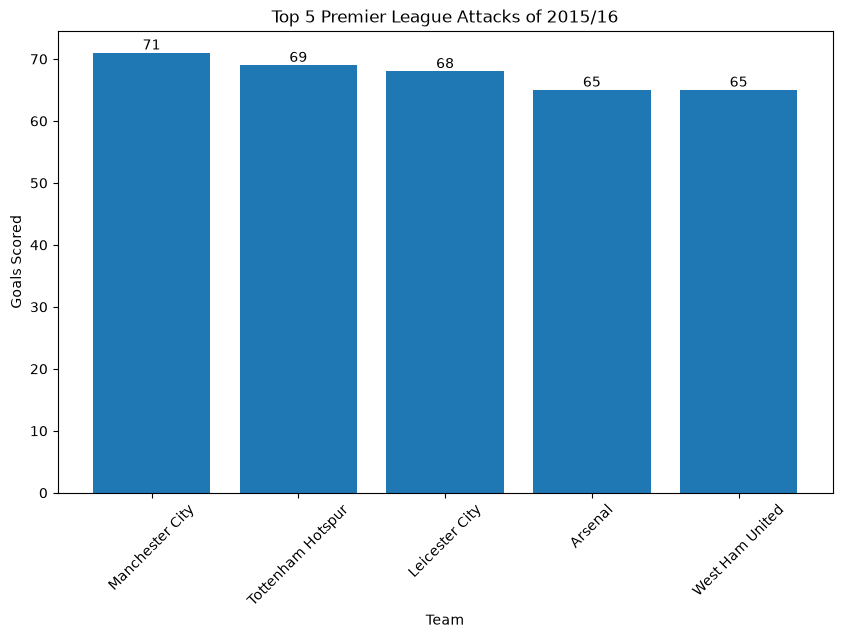

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(
    topAttacks.head(5).index, 
    topAttacks["GF"].head(5)
    )

plt.bar_label(bars)

plt.title("Top 5 Premier League Attacks of 2015/16")
plt.xlabel("Team")
plt.ylabel("Goals Scored")

plt.xticks(rotation=45)
plt.show()


In [53]:
# How many 1 goal wins did each team have

matches["goal_difference"] = matches.apply(
    lambda match: abs(match["home_score"] - match["away_score"]),
    axis=1
)

oneGoalGames = matches[matches["goal_difference"] == 1]

oneGoalGames["winner"] = oneGoalGames.apply(
    lambda match: match["home_team_name"] if match["result"] == "Home Win" else match["away_team_name"],
    axis=1
)

# count how many times each unique value appears
totalOneGoalWins = oneGoalGames["winner"].value_counts()

print(totalOneGoalWins)

winner
Leicester City          14
Manchester United       12
West Bromwich Albion    10
Stoke City              10
Liverpool                9
Swansea City             9
Watford                  8
Crystal Palace           8
Arsenal                  7
West Ham United          7
AFC Bournemouth          7
Southampton              7
Tottenham Hotspur        6
Manchester City          6
Norwich City             5
Chelsea                  5
Newcastle United         5
Everton                  3
Sunderland               3
Aston Villa              2
Name: count, dtype: int64


In [63]:
# How many points did each team earn at home versus away?

matches["home_points"] = matches.apply(
    lambda match: 3 if match["result"] == "Home Win" 
    else 1 if match["result"] == "Draw"
    else 0,
    axis=1
)

matches["away_points"] = matches.apply(
    lambda match: 3 if match["result"] == "Away Win" 
    else 1 if match["result"] == "Draw"
    else 0,
    axis=1
)
matches[["home_team_name", "away_team_name", "result", "home_points", "away_points"]].head(10)

,home_team_name,away_team_name,result,home_points,away_points
0,Chelsea,Arsenal,Home Win,3,0
1,Aston Villa,Arsenal,Away Win,0,3
2,Arsenal,Manchester City,Home Win,3,0
3,Swansea City,Arsenal,Away Win,0,3
4,Arsenal,Sunderland,Home Win,3,0
5,Arsenal,Liverpool,Draw,1,1
6,Southampton,Arsenal,Home Win,3,0
7,Liverpool,Swansea City,Home Win,3,0
8,Leicester City,AFC Bournemouth,Draw,1,1
9,West Bromwich Albion,Sunderland,Home Win,3,0


In [66]:
totalHomePoints = matches.groupby("home_team_name")["home_points"].sum()

print(totalHomePoints.sort_values(ascending=False))

home_team_name
Leicester City          42
Manchester United       41
Arsenal                 40
Manchester City         38
Tottenham Hotspur       36
Southampton             36
West Ham United         34
Liverpool               32
Swansea City            30
Stoke City              28
Newcastle United        28
Chelsea                 24
Watford                 24
Sunderland              24
Everton                 23
Norwich City            23
West Bromwich Albion    23
Crystal Palace          21
AFC Bournemouth         20
Aston Villa             11
Name: home_points, dtype: int64


In [68]:
totalAwayPoints = matches.groupby("away_team_name")["away_points"].sum()

print(totalAwayPoints.sort_values(ascending=False))

away_team_name
Leicester City          39
Tottenham Hotspur       34
Arsenal                 31
Manchester City         28
West Ham United         28
Liverpool               28
Southampton             27
Chelsea                 26
Manchester United       25
Everton                 24
Stoke City              23
AFC Bournemouth         22
Crystal Palace          21
Watford                 21
West Bromwich Albion    20
Swansea City            17
Sunderland              15
Norwich City            11
Newcastle United         9
Aston Villa              6
Name: away_points, dtype: int64


In [71]:
top5 = table.head(5)

top5["home_points"] = totalHomePoints
top5["away_points"] = totalAwayPoints

top5

,Wins,Draws,Losses,Points,GF,GA,GD,home_points,away_points
home_team_name,,,,,,,,,
Leicester City,23,12,3,81,68,36,32,42,39
Arsenal,20,11,7,71,65,36,29,40,31
Tottenham Hotspur,19,13,6,70,69,35,34,36,34
Manchester City,19,9,10,66,71,41,30,38,28
Manchester United,19,9,10,66,49,35,14,41,25


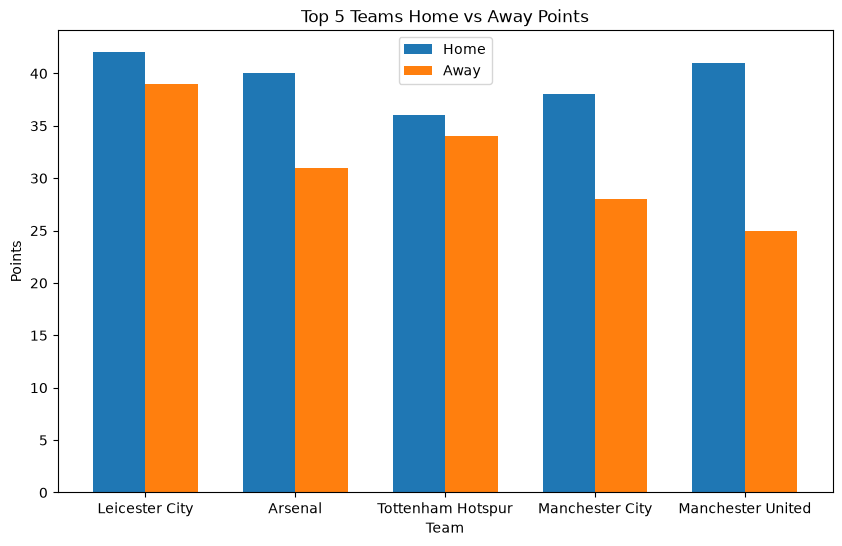

In [79]:
import numpy as np

# plt.bar(
#     top5.index,
#     top5["home_points"],
#     top5["away_points"]
# )

x = np.arange(len(top5))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2, 
    top5["home_points"], 
    width, label="Home"
    )

plt.bar(
    x + width/2,
    top5["away_points"], 
    width, label="Away"
    )

plt.xticks(x, top5.index)

plt.title("Top 5 Teams Home vs Away Points")
plt.xlabel("Team")
plt.ylabel("Points")

plt.legend()
plt.show()

In [96]:
# Which teams were most efficient at turning goals into points?

table["points_per_goal"] = table["Points"] / table["GF"]

table

,Wins,Draws,Losses,Points,GF,GA,GD,points-per_Goal,points_per_goal
home_team_name,,,,,,,,,
Leicester City,23,12,3,81,68,36,32,1.191176,1.191176
Arsenal,20,11,7,71,65,36,29,1.092308,1.092308
Tottenham Hotspur,19,13,6,70,69,35,34,1.014493,1.014493
Manchester City,19,9,10,66,71,41,30,0.929577,0.929577
Manchester United,19,9,10,66,49,35,14,1.346939,1.346939
Southampton,18,9,11,63,59,41,18,1.067797,1.067797
West Ham United,16,14,8,62,65,51,14,0.953846,0.953846
Liverpool,16,12,10,60,63,50,13,0.952381,0.952381
Stoke City,14,9,15,51,41,55,-14,1.243902,1.243902


In [97]:
mostEfficient = table.sort_values(by= "points_per_goal", ascending=False)

mostEfficient

,Wins,Draws,Losses,Points,GF,GA,GD,points-per_Goal,points_per_goal
home_team_name,,,,,,,,,
Manchester United,19,9,10,66,49,35,14,1.346939,1.346939
West Bromwich Albion,10,13,15,43,34,48,-14,1.264706,1.264706
Stoke City,14,9,15,51,41,55,-14,1.243902,1.243902
Leicester City,23,12,3,81,68,36,32,1.191176,1.191176
Watford,12,9,17,45,40,50,-10,1.125000,1.125000
Swansea City,12,11,15,47,42,52,-10,1.119048,1.119048
Arsenal,20,11,7,71,65,36,29,1.092308,1.092308
Crystal Palace,11,9,18,42,39,51,-12,1.076923,1.076923
Southampton,18,9,11,63,59,41,18,1.067797,1.067797
